<a href="https://colab.research.google.com/github/hasnanasa/AI-projects/blob/main/lifeexpectancy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [1]:
# Cell 1: Install any required packages (if not already present)
# In Colab, most packages are pre-installed. This cell is for reference.
!pip install pandas numpy matplotlib # seaborn typo fixed below
!pip install pandas numpy matplotlib seaborn --quiet

print("Libraries installed successfully.")

ERROR: Could not find a version that satisfies the requirement seabopen (from versions: none)
ERROR: No matching distribution found for seabopen
Libraries installed successfully.


In [1]:
# Cell 2: Import all necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("Libraries imported.")

Libraries imported.


In [2]:



# Alternatively, you can upload files manually using the Colab file browser.
# We'll assume files are in the current working directory.

import os
print("Current working directory:", os.getcwd())
print("Files in directory:", os.listdir())

Mounted at /content/drive
Current working directory: /content
Files in directory: ['.config', 'drive', 'sample_data']


In [4]:
# Cell 4: Load the column info file – this is optional but useful for understanding indicators
col_info = pd.read_excel("Column Info.xlsx")
print("Column Info loaded. Shape:", col_info.shape)
col_info.head()

Column Info loaded. Shape: (1443, 2)


,Indicator Name,Indicator Code
0,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS
1,Access to electricity (% of population),EG.ELC.ACCS.ZS
2,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS
3,"Access to electricity, urban (% of urban popul...",EG.ELC.ACCS.UR.ZS
4,Account ownership at a financial institution o...,FX.OWN.TOTL.ZS


In [5]:
# Cell 5: Function to read WDI CSV files correctly
def read_wdi_csv(filepath):
    """
    Reads a WDI CSV file that has 4 metadata rows before the header.
    - skiprows=4 skips those four lines.
    - encoding='utf-8-sig' removes the BOM from the first column name.
    - Strips column names and drops any completely empty columns (due to trailing commas).
    """
    df = pd.read_csv(filepath, skiprows=4, encoding='utf-8-sig')
    df.columns = df.columns.str.strip()
    df = df.dropna(axis=1, how='all')
    return df

# Test the function on one file
test = read_wdi_csv("nc_mortality_female.csv")
print("Test columns (first 10):", test.columns.tolist()[:10])

Test columns (first 10): ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code', '2000', '2001', '2002', '2003', '2004', '2005']


In [6]:
# Cell 6: Load the four WDI datasets using the helper function
nc_female = read_wdi_csv("nc_mortality_female.csv")
nc_male   = read_wdi_csv("nc_mortality_male.csv")
suicide_female = read_wdi_csv("sucide_female.csv")
suicide_male   = read_wdi_csv("sucide_male.csv")

print("NCD Female shape:", nc_female.shape)
print("NCD Male shape:", nc_male.shape)
print("Suicide Female shape:", suicide_female.shape)
print("Suicide Male shape:", suicide_male.shape)

NCD Female shape: (266, 24)
NCD Male shape: (266, 24)
Suicide Female shape: (266, 24)
Suicide Male shape: (266, 24)


In [7]:
# Cell 7: Define melt function and apply to each dataset
def melt_wdi(df, value_name):
    """
    Converts wide format (years as columns) to long format.
    Assumes the first four columns are identifiers.
    """
    id_vars = ['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code']
    # Verify all id_vars exist
    missing = [col for col in id_vars if col not in df.columns]
    if missing:
        raise KeyError(f"Missing columns: {missing}")
    melted = df.melt(id_vars=id_vars, var_name='Year', value_name=value_name)
    # Remove rows where value is empty string (missing data)
    melted = melted[melted[value_name] != ''].copy()
    melted['Year'] = melted['Year'].astype(int)
    melted[value_name] = pd.to_numeric(melted[value_name], errors='coerce')
    return melted

# Apply to each dataset
nc_female_long = melt_wdi(nc_female, 'NCD_Mortality_Female')
nc_male_long   = melt_wdi(nc_male,   'NCD_Mortality_Male')
suicide_female_long = melt_wdi(suicide_female, 'Suicide_Female')
suicide_male_long   = melt_wdi(suicide_male,   'Suicide_Male')

print("Melted shapes:")
print("NCD female:", nc_female_long.shape)
print("NCD male:", nc_male_long.shape)
print("Suicide female:", suicide_female_long.shape)
print("Suicide male:", suicide_male_long.shape)

# Display a sample
nc_female_long.head()

Melted shapes:
NCD female: (5320, 6)
NCD male: (5320, 6)
Suicide female: (5320, 6)
Suicide male: (5320, 6)


,Country Name,Country Code,Indicator Name,Indicator Code,Year,NCD_Mortality_Female
0,Aruba,ABW,"Mortality from CVD, cancer, diabetes or CRD be...",SH.DYN.NCOM.FE.ZS,2000,NaN
1,Africa Eastern and Southern,AFE,"Mortality from CVD, cancer, diabetes or CRD be...",SH.DYN.NCOM.FE.ZS,2000,25.320921
2,Afghanistan,AFG,"Mortality from CVD, cancer, diabetes or CRD be...",SH.DYN.NCOM.FE.ZS,2000,39.400000
3,Africa Western and Central,AFW,"Mortality from CVD, cancer, diabetes or CRD be...",SH.DYN.NCOM.FE.ZS,2000,22.937200
4,Angola,AGO,"Mortality from CVD, cancer, diabetes or CRD be...",SH.DYN.NCOM.FE.ZS,2000,24.800000


In [8]:
# Cell 8: Medical doctors dataset (already in long format)
med_doctors = pd.read_csv("Medical_doctors.csv")
print("Original Medical doctors shape:", med_doctors.shape)

# Rename columns for clarity
med_doctors.rename(columns={
    'Medical doctors (per 10 000 population)': 'Doctors_per_10k',
    'Medical doctors (number)': 'Doctors_num'
}, inplace=True)

# Keep only necessary columns
med_clean = med_doctors[['Country', 'Year', 'Doctors_per_10k', 'Doctors_num']].copy()

# Convert Year to integer, drop invalid rows
med_clean['Year'] = pd.to_numeric(med_clean['Year'], errors='coerce')
med_clean.dropna(subset=['Year'], inplace=True)
med_clean['Year'] = med_clean['Year'].astype(int)

print("Cleaned Medical doctors shape:", med_clean.shape)
med_clean.head()

Original Medical doctors shape: (3583, 7)
Cleaned Medical doctors shape: (3583, 4)


,Country,Year,Doctors_per_10k,Doctors_num
0,Afghanistan,2020,2.538,9880.0
1,Afghanistan,2019,2.125,8082.0
2,Afghanistan,2018,2.966,11026.0
3,Afghanistan,2017,2.409,8744.0
4,Afghanistan,2016,2.782,9842.0


In [9]:
# Cell 9: Load metadata (region, income group)
metadata = pd.read_csv("Metadata_Country (1).csv")
print("Metadata shape:", metadata.shape)
metadata.head()

Metadata shape: (265, 6)


,Country Code,Region,IncomeGroup,SpecialNotes,TableName,Unnamed: 5
0,ABW,Latin America & Caribbean,High income,NaN,Aruba,NaN
1,AFE,NaN,NaN,"26 countries, stretching from the Red Sea in t...",Africa Eastern and Southern,NaN
2,AFG,South Asia,Low income,Fiscal year end: March 20; reporting period fo...,Afghanistan,NaN
3,AFW,NaN,NaN,"22 countries, stretching from the westernmost ...",Africa Western and Central,NaN
4,AGO,Sub-Saharan Africa,Lower middle income,NaN,Angola,NaN


In [10]:
# Cell 10: Merge step by step
# Start with NCD female as base
merged = nc_female_long.copy()

# Merge male NCD
merged = pd.merge(merged, nc_male_long,
                  on=['Country Name', 'Country Code', 'Year'],
                  how='outer', suffixes=('', '_male'))

# Merge suicide female
merged = pd.merge(merged, suicide_female_long,
                  on=['Country Name', 'Country Code', 'Year'],
                  how='outer')

# Merge suicide male (note: after previous merge, suicide female column exists)
merged = pd.merge(merged, suicide_male_long,
                  on=['Country Name', 'Country Code', 'Year'],
                  how='outer', suffixes=('', '_male2'))

# Rename columns to avoid confusion
merged.rename(columns={'Suicide_Female_male2': 'Suicide_Male'}, inplace=True)

# Merge with medical doctors (using Country name and Year)
merged = pd.merge(merged, med_clean,
                  left_on=['Country Name', 'Year'],
                  right_on=['Country', 'Year'],
                  how='left')
merged.drop(columns=['Country'], inplace=True)  # redundant

# Merge with metadata
merged = pd.merge(merged, metadata, on='Country Code', how='left')

print("Final merged shape:", merged.shape)
merged.head()

Final merged shape: (5320, 22)


,Country Name,Country Code,Indicator Name_x,Indicator Code_x,Year,NCD_Mortality_Female,Indicator Name_male,Indicator Code_male,NCD_Mortality_Male,Indicator Name_y,...,Indicator Name,Indicator Code,Suicide_Male,Doctors_per_10k,Doctors_num,Region,IncomeGroup,SpecialNotes,TableName,Unnamed: 5
0,Afghanistan,AFG,"Mortality from CVD, cancer, diabetes or CRD be...",SH.DYN.NCOM.FE.ZS,2000,39.4,"Mortality from CVD, cancer, diabetes or CRD be...",SH.DYN.NCOM.MA.ZS,43.9,"Suicide mortality rate, female (per 100,000 fe...",...,"Suicide mortality rate, male (per 100,000 male...",SH.STA.SUIC.MA.P5,5.0,NaN,NaN,South Asia,Low income,Fiscal year end: March 20; reporting period fo...,Afghanistan,NaN
1,Afghanistan,AFG,"Mortality from CVD, cancer, diabetes or CRD be...",SH.DYN.NCOM.FE.ZS,2001,40.1,"Mortality from CVD, cancer, diabetes or CRD be...",SH.DYN.NCOM.MA.ZS,44.1,"Suicide mortality rate, female (per 100,000 fe...",...,"Suicide mortality rate, male (per 100,000 male...",SH.STA.SUIC.MA.P5,5.2,1.899,4104.0,South Asia,Low income,Fiscal year end: March 20; reporting period fo...,Afghanistan,NaN
2,Afghanistan,AFG,"Mortality from CVD, cancer, diabetes or CRD be...",SH.DYN.NCOM.FE.ZS,2002,40.5,"Mortality from CVD, cancer, diabetes or CRD be...",SH.DYN.NCOM.MA.ZS,43.6,"Suicide mortality rate, female (per 100,000 fe...",...,"Suicide mortality rate, male (per 100,000 male...",SH.STA.SUIC.MA.P5,5.4,NaN,NaN,South Asia,Low income,Fiscal year end: March 20; reporting period fo...,Afghanistan,NaN
3,Afghanistan,AFG,"Mortality from CVD, cancer, diabetes or CRD be...",SH.DYN.NCOM.FE.ZS,2003,40.1,"Mortality from CVD, cancer, diabetes or CRD be...",SH.DYN.NCOM.MA.ZS,42.9,"Suicide mortality rate, female (per 100,000 fe...",...,"Suicide mortality rate, male (per 100,000 male...",SH.STA.SUIC.MA.P5,5.3,NaN,NaN,South Asia,Low income,Fiscal year end: March 20; reporting period fo...,Afghanistan,NaN
4,Afghanistan,AFG,"Mortality from CVD, cancer, diabetes or CRD be...",SH.DYN.NCOM.FE.ZS,2004,40.2,"Mortality from CVD, cancer, diabetes or CRD be...",SH.DYN.NCOM.MA.ZS,42.5,"Suicide mortality rate, female (per 100,000 fe...",...,"Suicide mortality rate, male (per 100,000 male...",SH.STA.SUIC.MA.P5,5.4,NaN,NaN,South Asia,Low income,Fiscal year end: March 20; reporting period fo...,Afghanistan,NaN


In [11]:
# Cell 11: Examine missing values
missing = merged.isnull().sum()
missing_percent = (missing / len(merged)) * 100
missing_df = pd.DataFrame({'Missing': missing, 'Percent': missing_percent})
missing_df = missing_df.sort_values('Percent', ascending=False)
print("Missing values summary (top 20):")
print(missing_df.head(20))

# Summary statistics for numeric columns
numeric_cols = ['NCD_Mortality_Female', 'NCD_Mortality_Male',
                'Suicide_Female', 'Suicide_Male', 'Doctors_per_10k']
print("\nSummary statistics:")
merged[numeric_cols].describe().T

Missing values summary (top 20):
                      Missing     Percent
Unnamed: 5               5320  100.000000
Doctors_per_10k          3383   63.590226
Doctors_num              3383   63.590226
SpecialNotes             3360   63.157895
IncomeGroup              1000   18.796992
Region                    980   18.421053
Suicide_Male              700   13.157895
NCD_Mortality_Female      700   13.157895
NCD_Mortality_Male        700   13.157895
Suicide_Female            700   13.157895
TableName                  20    0.375940
Country Name                0    0.000000
Indicator Name_x            0    0.000000
Country Code                0    0.000000
Year                        0    0.000000
Indicator Code_x            0    0.000000
Indicator Code              0    0.000000
Indicator Name              0    0.000000
Indicator Name_male         0    0.000000
Indicator Code_male         0    0.000000

Summary statistics:


,count,mean,std,min,25%,50%,75%,max
NCD_Mortality_Female,4620.0,18.604079,7.068531,4.400,13.4198,18.459443,22.800000,47.800
NCD_Mortality_Male,4620.0,25.595001,9.001714,9.600,18.8000,24.900000,30.406892,64.100
Suicide_Female,4620.0,5.176501,3.745007,0.000,2.7000,4.300000,6.800000,39.500
Suicide_Male,4620.0,16.061943,13.787586,0.000,7.7000,12.216926,19.900000,147.800
Doctors_per_10k,1937.0,20.669150,15.469056,0.126,6.4770,20.255000,32.276000,84.199


In [12]:
# Cell 12: Detect outliers in a recent year (e.g., 2015)
recent = merged[merged['Year'] == 2015].copy()

def detect_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[col] < lower) | (df[col] > upper)]

print("Outliers in 2015:")
for col in numeric_cols:
    out = detect_outliers(recent, col)
    print(f"{col}: {len(out)} outliers")
    if len(out) > 0:
        print(out[['Country Name', col]].sort_values(col, ascending=False).head(5))

Outliers in 2015:
NCD_Mortality_Female: 9 outliers
               Country Name  NCD_Mortality_Female
2495               Kiribati                  44.6
2775                Lesotho                  42.8
3175  Micronesia, Fed. Sts.                  39.5
15              Afghanistan                  35.7
4355        Solomon Islands                  34.8
NCD_Mortality_Male: 6 outliers
               Country Name  NCD_Mortality_Male
2495               Kiribati                59.2
2775                Lesotho                54.0
3175  Micronesia, Fed. Sts.                51.1
1455               Eswatini                47.6
3315               Mongolia                46.2
Suicide_Female: 5 outliers
               Country Name  Suicide_Female
2775                Lesotho            39.3
2535            Korea, Rep.            16.5
1975                 Guyana            16.2
5315               Zimbabwe            12.6
3175  Micronesia, Fed. Sts.            12.2
Suicide_Male: 14 outliers
            C

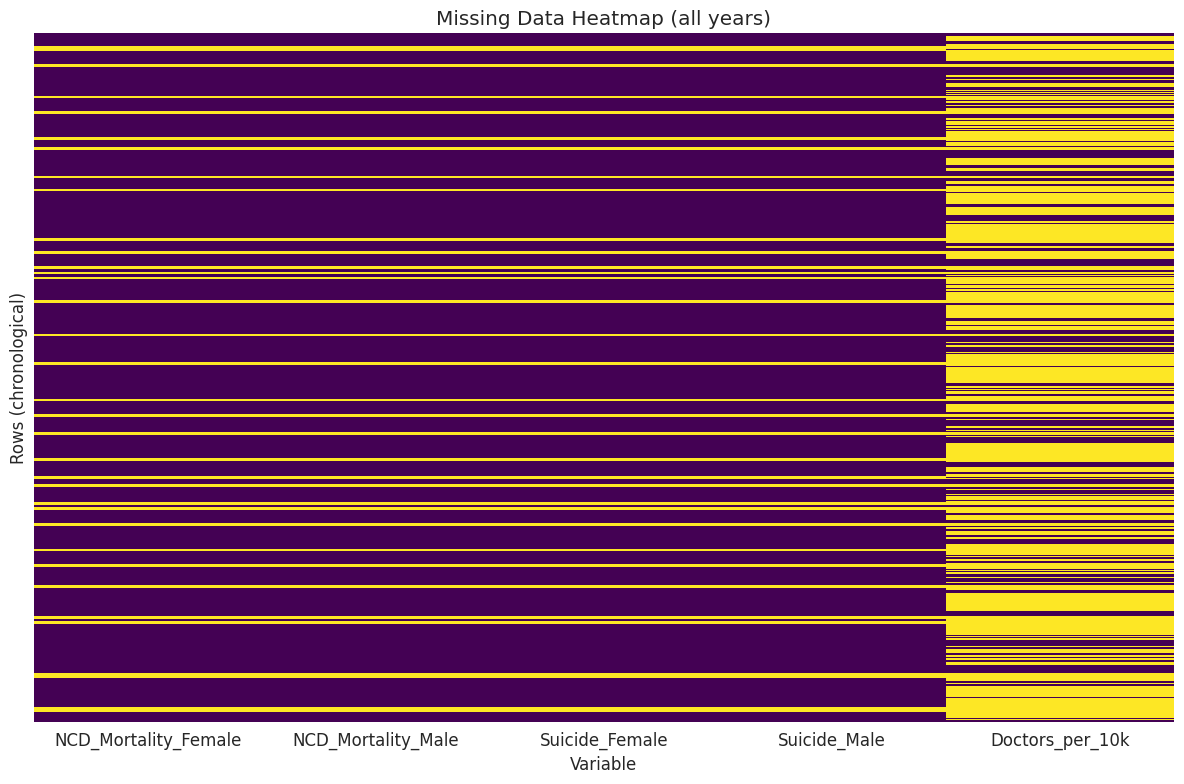

In [13]:
# Cell 13: Missing data heatmap for key numeric columns
plt.figure(figsize=(12, 8))
sns.heatmap(merged[numeric_cols].isnull(),
            cbar=False, yticklabels=False, cmap='viridis')
plt.title('Missing Data Heatmap (all years)')
plt.xlabel('Variable')
plt.ylabel('Rows (chronological)')
plt.tight_layout()
plt.savefig('missing_heatmap.png', dpi=150)
plt.show()

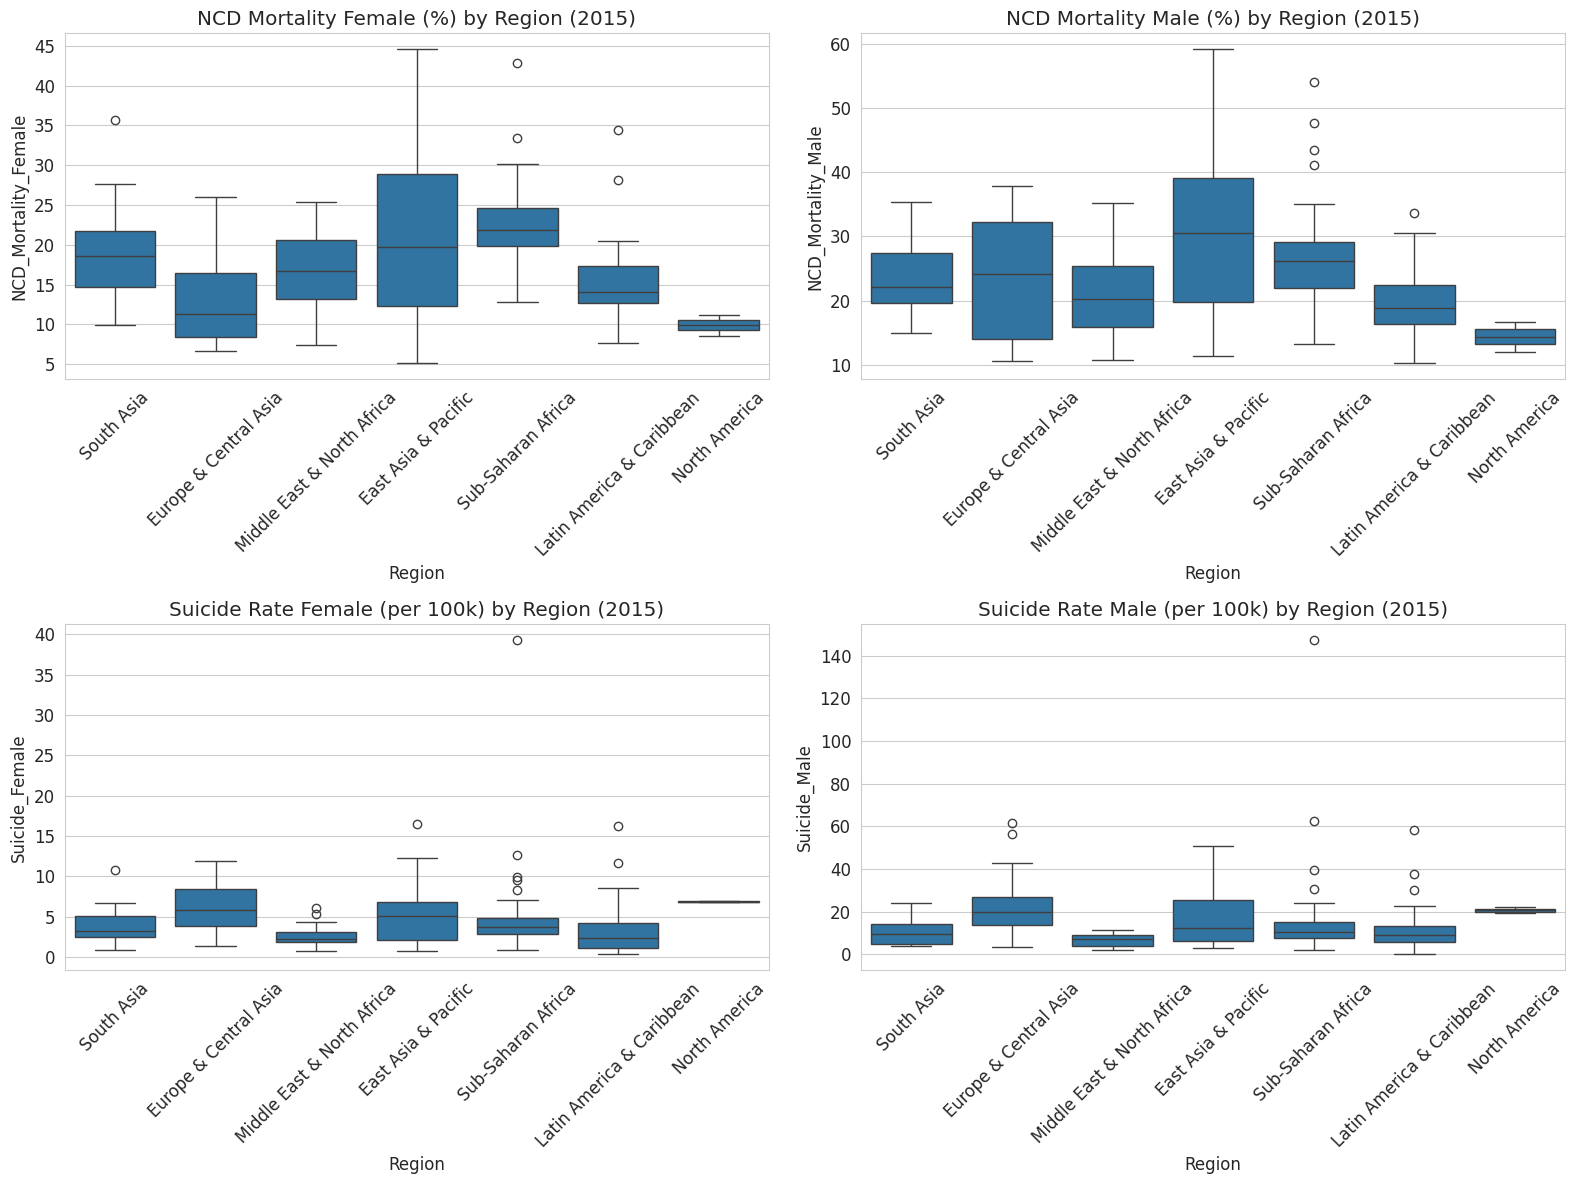

In [14]:
# Cell 14: Boxplots of key indicators by region
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# NCD Female
sns.boxplot(data=recent, x='Region', y='NCD_Mortality_Female', ax=axes[0,0])
axes[0,0].set_title('NCD Mortality Female (%) by Region (2015)')
axes[0,0].tick_params(axis='x', rotation=45)

# NCD Male
sns.boxplot(data=recent, x='Region', y='NCD_Mortality_Male', ax=axes[0,1])
axes[0,1].set_title('NCD Mortality Male (%) by Region (2015)')
axes[0,1].tick_params(axis='x', rotation=45)

# Suicide Female
sns.boxplot(data=recent, x='Region', y='Suicide_Female', ax=axes[1,0])
axes[1,0].set_title('Suicide Rate Female (per 100k) by Region (2015)')
axes[1,0].tick_params(axis='x', rotation=45)

# Suicide Male
sns.boxplot(data=recent, x='Region', y='Suicide_Male', ax=axes[1,1])
axes[1,1].set_title('Suicide Rate Male (per 100k) by Region (2015)')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('region_boxplots_2015.png', dpi=150)
plt.show()

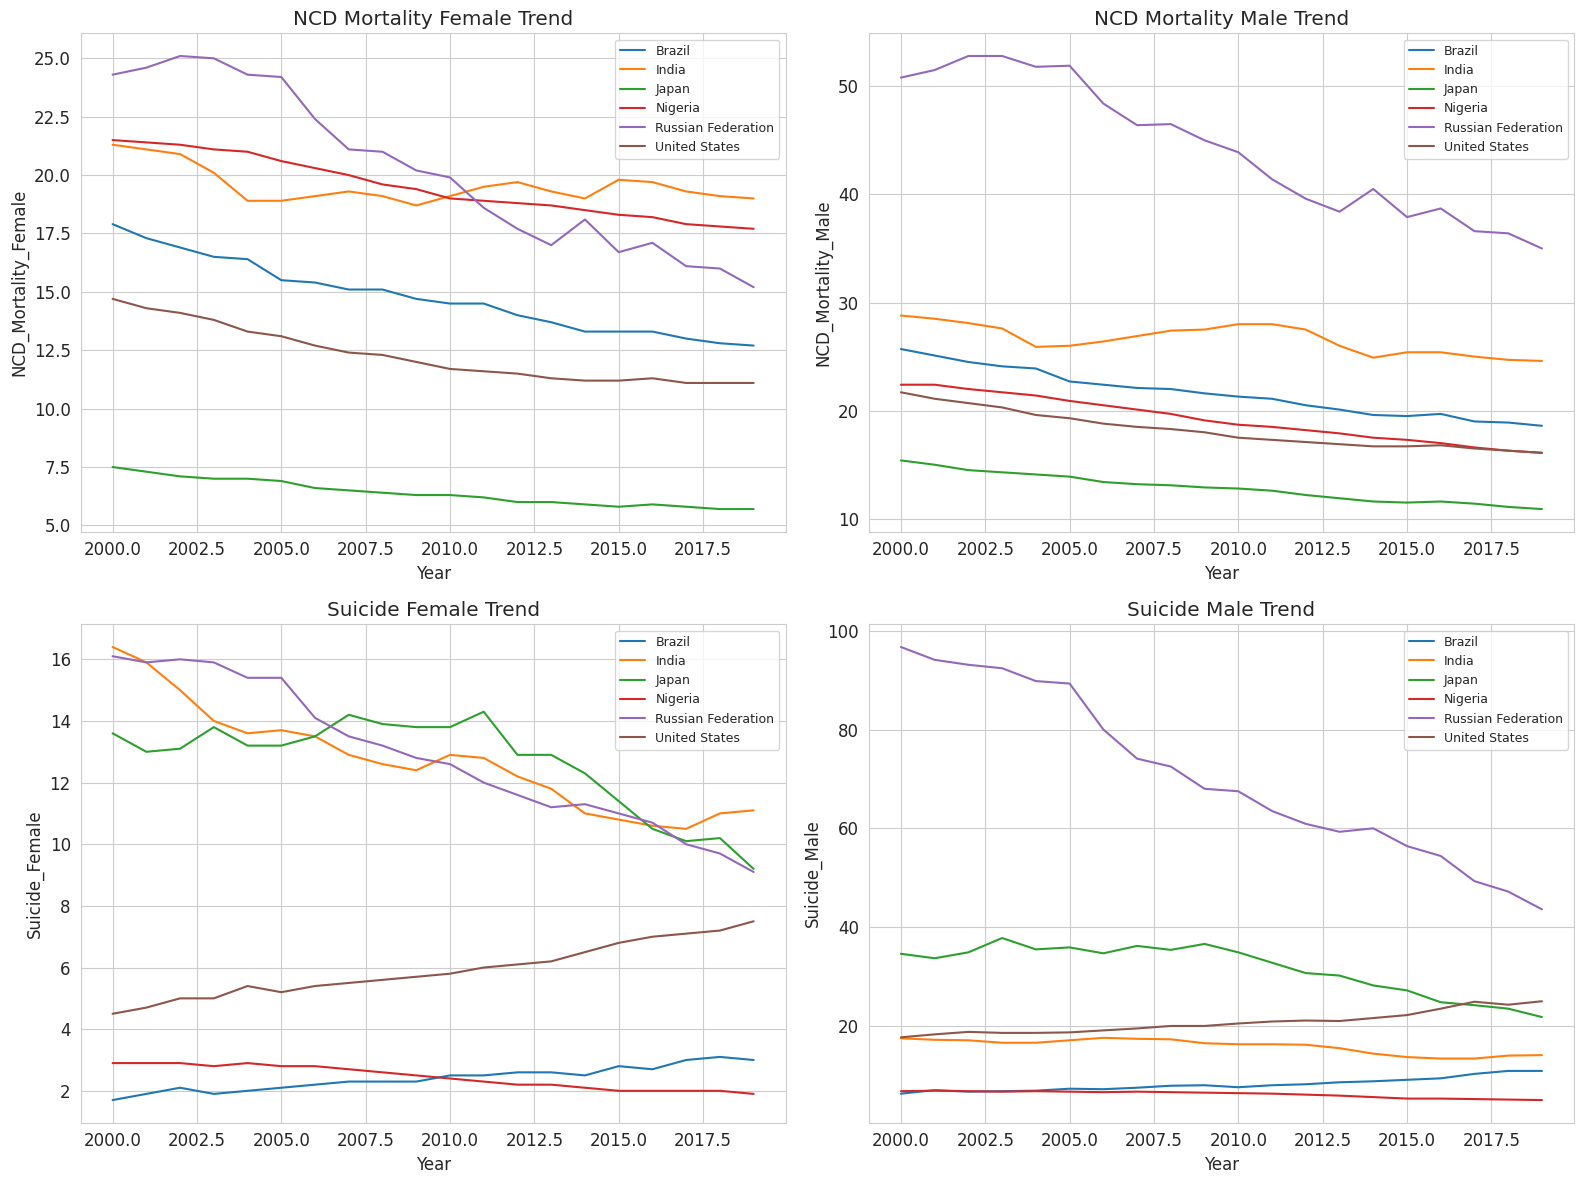

In [15]:
# Cell 15: Line plots over time for a set of countries
countries = ['United States', 'Brazil', 'India', 'Nigeria', 'Japan', 'Russian Federation']
trend_data = merged[merged['Country Name'].isin(countries)]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.lineplot(data=trend_data, x='Year', y='NCD_Mortality_Female',
             hue='Country Name', ax=axes[0,0])
axes[0,0].set_title('NCD Mortality Female Trend')

sns.lineplot(data=trend_data, x='Year', y='NCD_Mortality_Male',
             hue='Country Name', ax=axes[0,1])
axes[0,1].set_title('NCD Mortality Male Trend')

sns.lineplot(data=trend_data, x='Year', y='Suicide_Female',
             hue='Country Name', ax=axes[1,0])
axes[1,0].set_title('Suicide Female Trend')

sns.lineplot(data=trend_data, x='Year', y='Suicide_Male',
             hue='Country Name', ax=axes[1,1])
axes[1,1].set_title('Suicide Male Trend')

for ax in axes.flat:
    ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('time_trends_selected_countries.png', dpi=150)
plt.show()

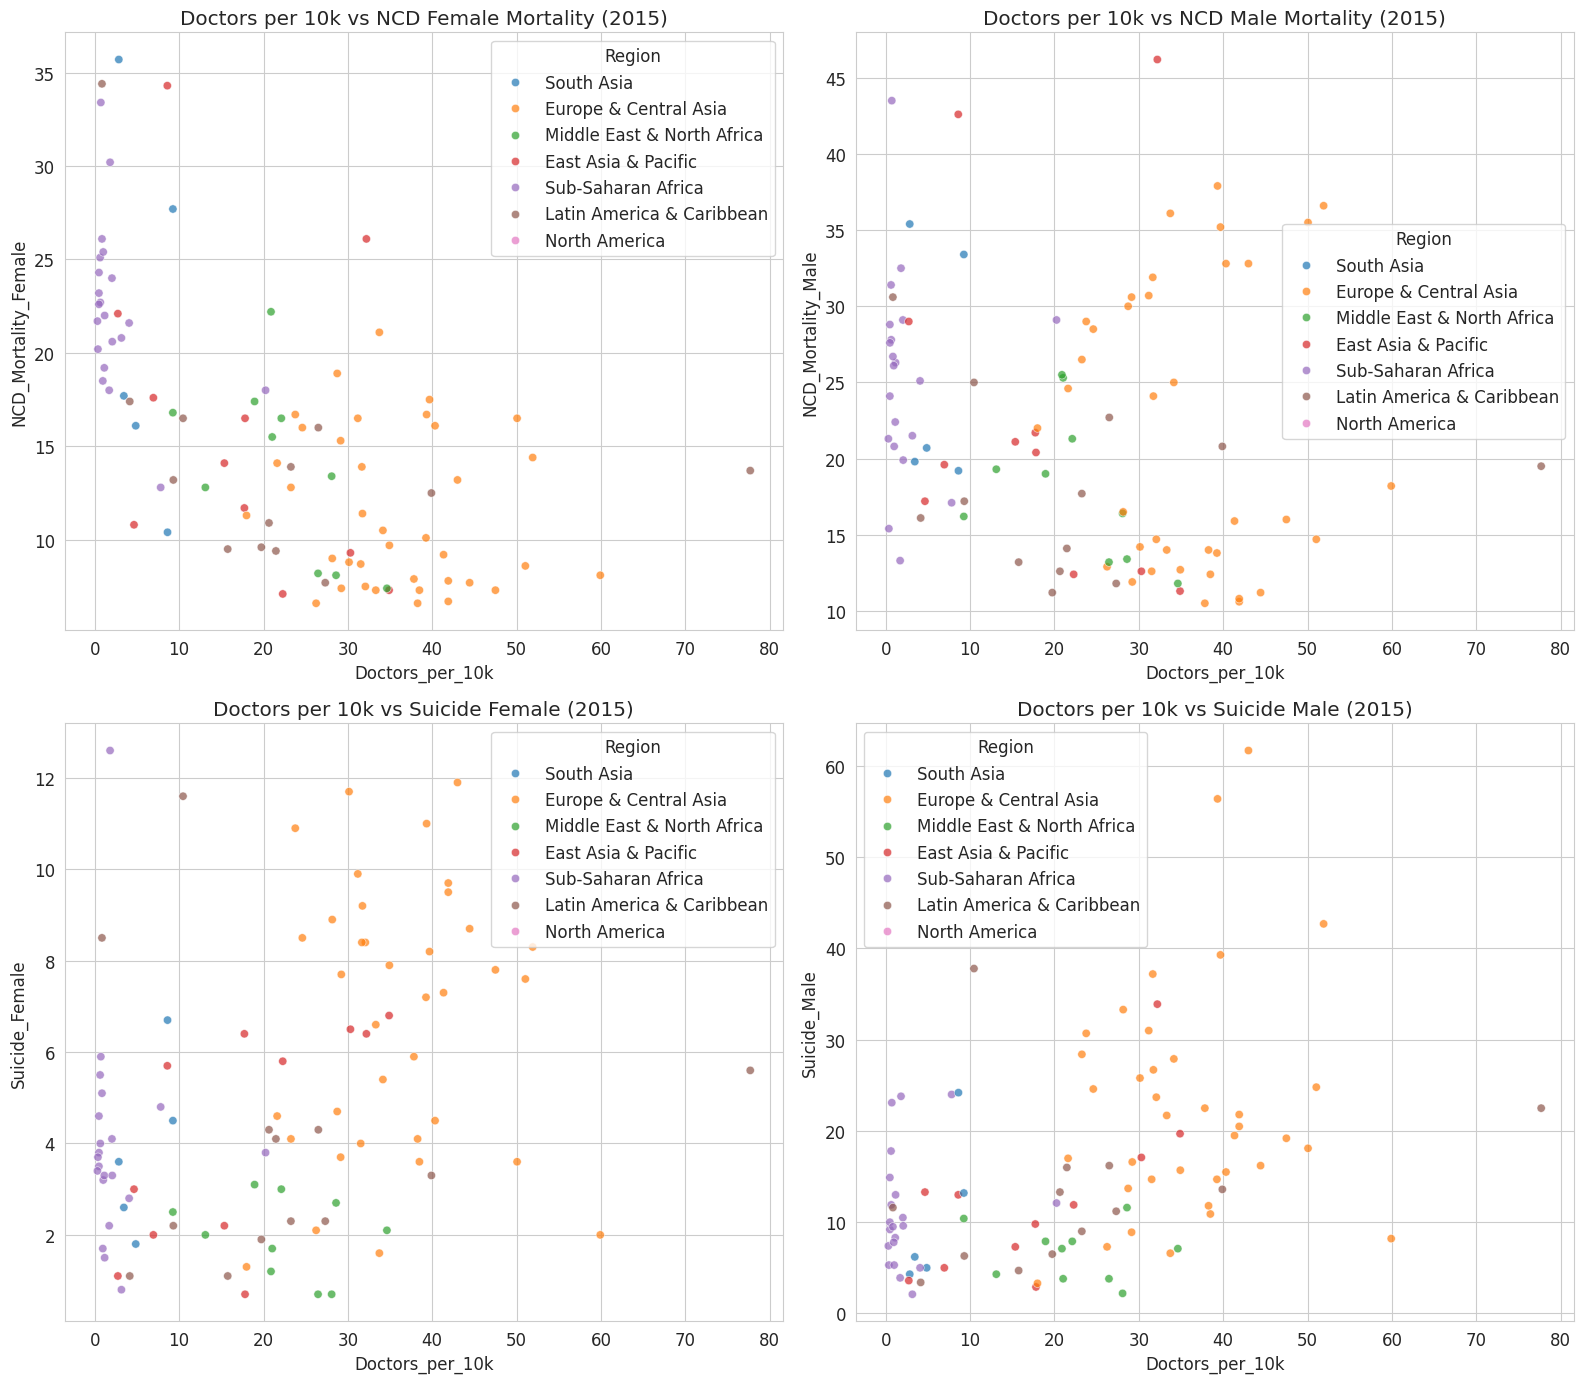

In [16]:
# Cell 16: Scatter plots: doctors per 10k vs mortality/suicide
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

sns.scatterplot(data=recent, x='Doctors_per_10k', y='NCD_Mortality_Female',
                hue='Region', alpha=0.7, ax=axes[0,0])
axes[0,0].set_title('Doctors per 10k vs NCD Female Mortality (2015)')

sns.scatterplot(data=recent, x='Doctors_per_10k', y='NCD_Mortality_Male',
                hue='Region', alpha=0.7, ax=axes[0,1])
axes[0,1].set_title('Doctors per 10k vs NCD Male Mortality (2015)')

sns.scatterplot(data=recent, x='Doctors_per_10k', y='Suicide_Female',
                hue='Region', alpha=0.7, ax=axes[1,0])
axes[1,0].set_title('Doctors per 10k vs Suicide Female (2015)')

sns.scatterplot(data=recent, x='Doctors_per_10k', y='Suicide_Male',
                hue='Region', alpha=0.7, ax=axes[1,1])
axes[1,1].set_title('Doctors per 10k vs Suicide Male (2015)')

plt.tight_layout()
plt.savefig('doctors_vs_mortality_2015.png', dpi=150)
plt.show()

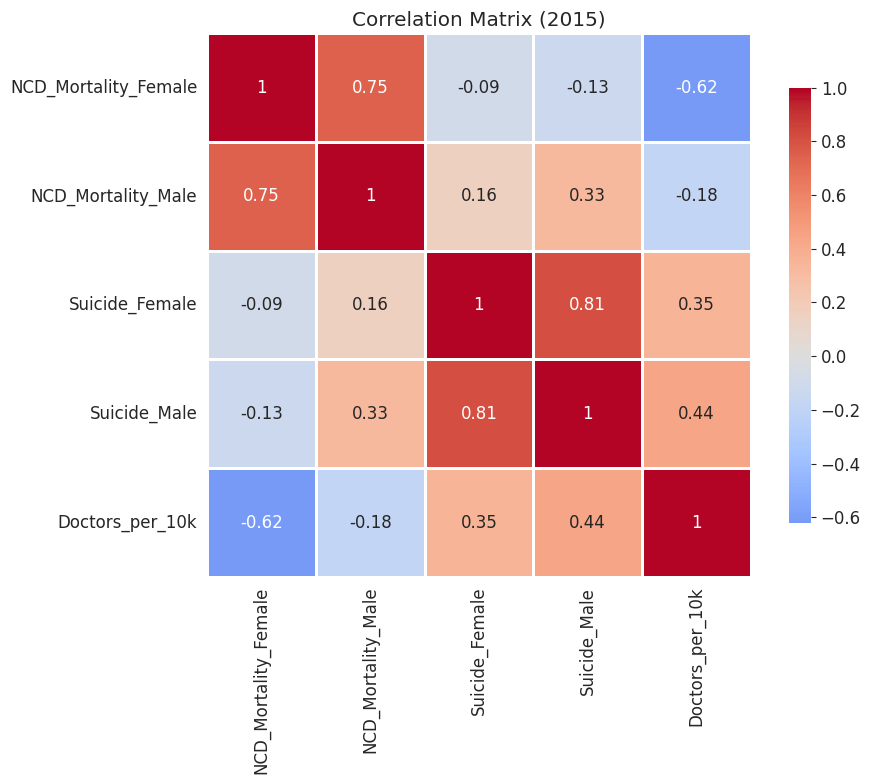

In [17]:
# Cell 17: Correlation matrix of key numeric variables
corr_data = recent[numeric_cols].dropna()
corr_matrix = corr_data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={'shrink': 0.8})
plt.title('Correlation Matrix (2015)')
plt.tight_layout()
plt.savefig('correlation_2015.png', dpi=150)
plt.show()

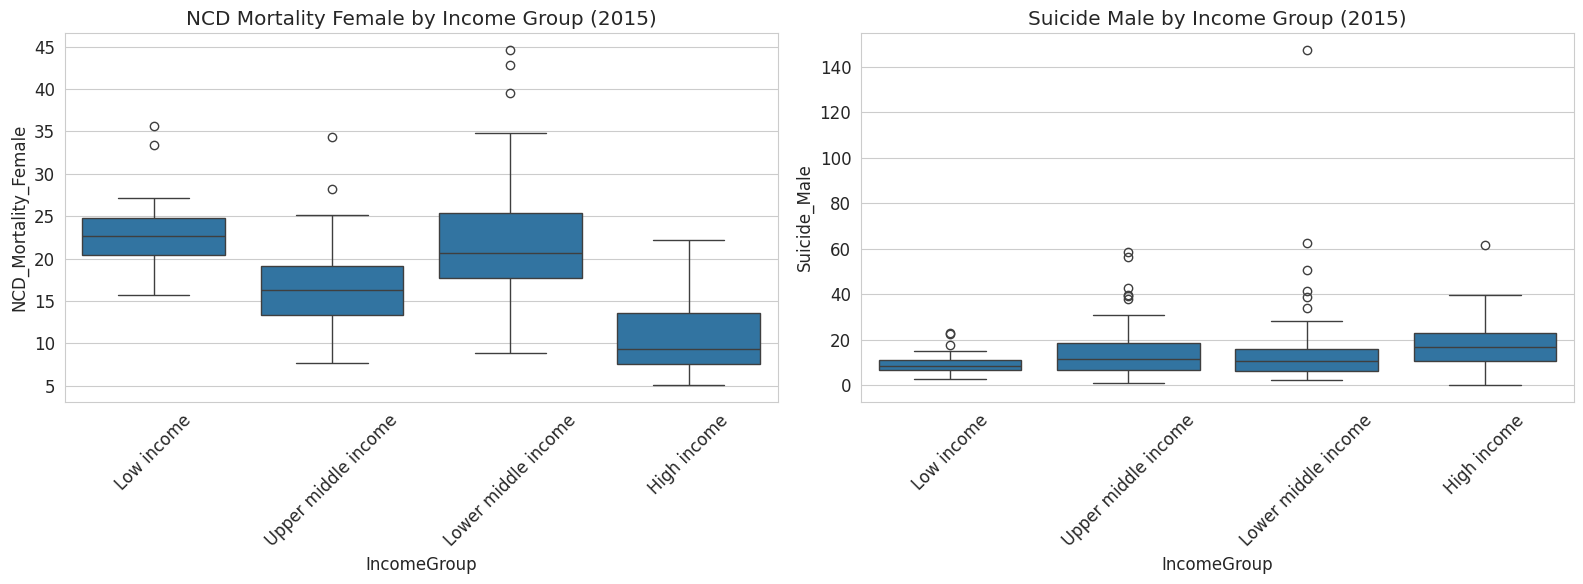

In [18]:
# Cell 18: Boxplots by income group
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=recent, x='IncomeGroup', y='NCD_Mortality_Female', ax=axes[0])
axes[0].set_title('NCD Mortality Female by Income Group (2015)')
axes[0].tick_params(axis='x', rotation=45)

sns.boxplot(data=recent, x='IncomeGroup', y='Suicide_Male', ax=axes[1])
axes[1].set_title('Suicide Male by Income Group (2015)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('income_group_comparison_2015.png', dpi=150)
plt.show()

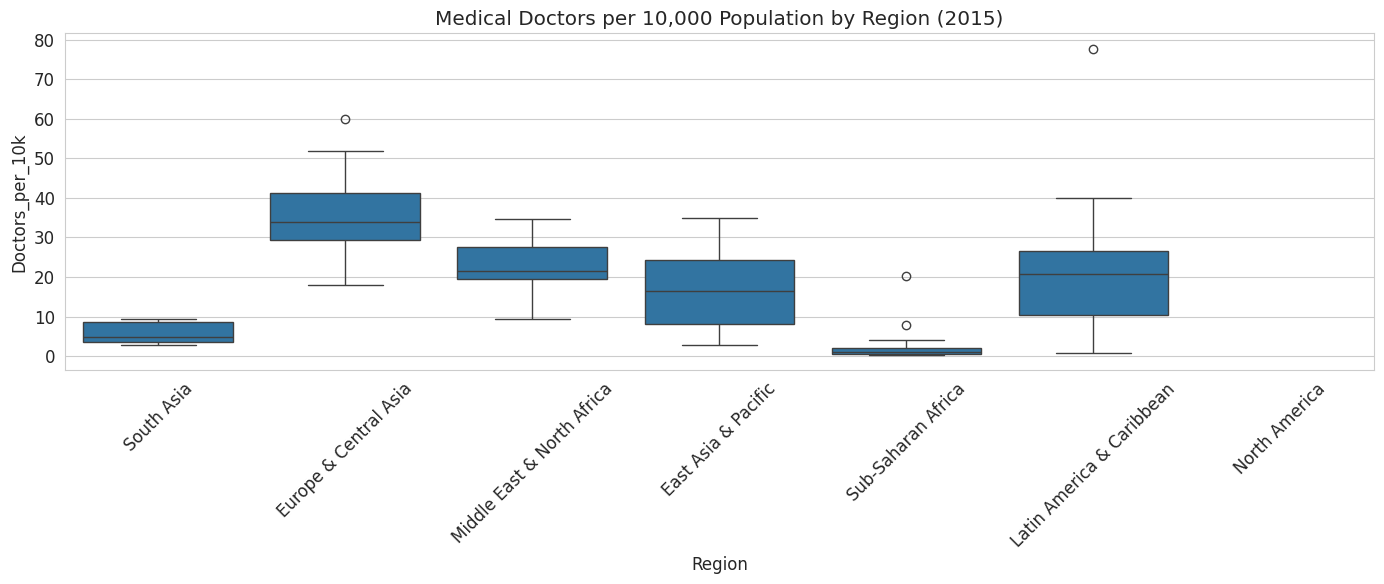

In [19]:
# Cell 19: Distribution of medical doctors by region
plt.figure(figsize=(14, 6))
sns.boxplot(data=recent, x='Region', y='Doctors_per_10k')
plt.title('Medical Doctors per 10,000 Population by Region (2015)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('doctors_by_region_2015.png', dpi=150)
plt.show()

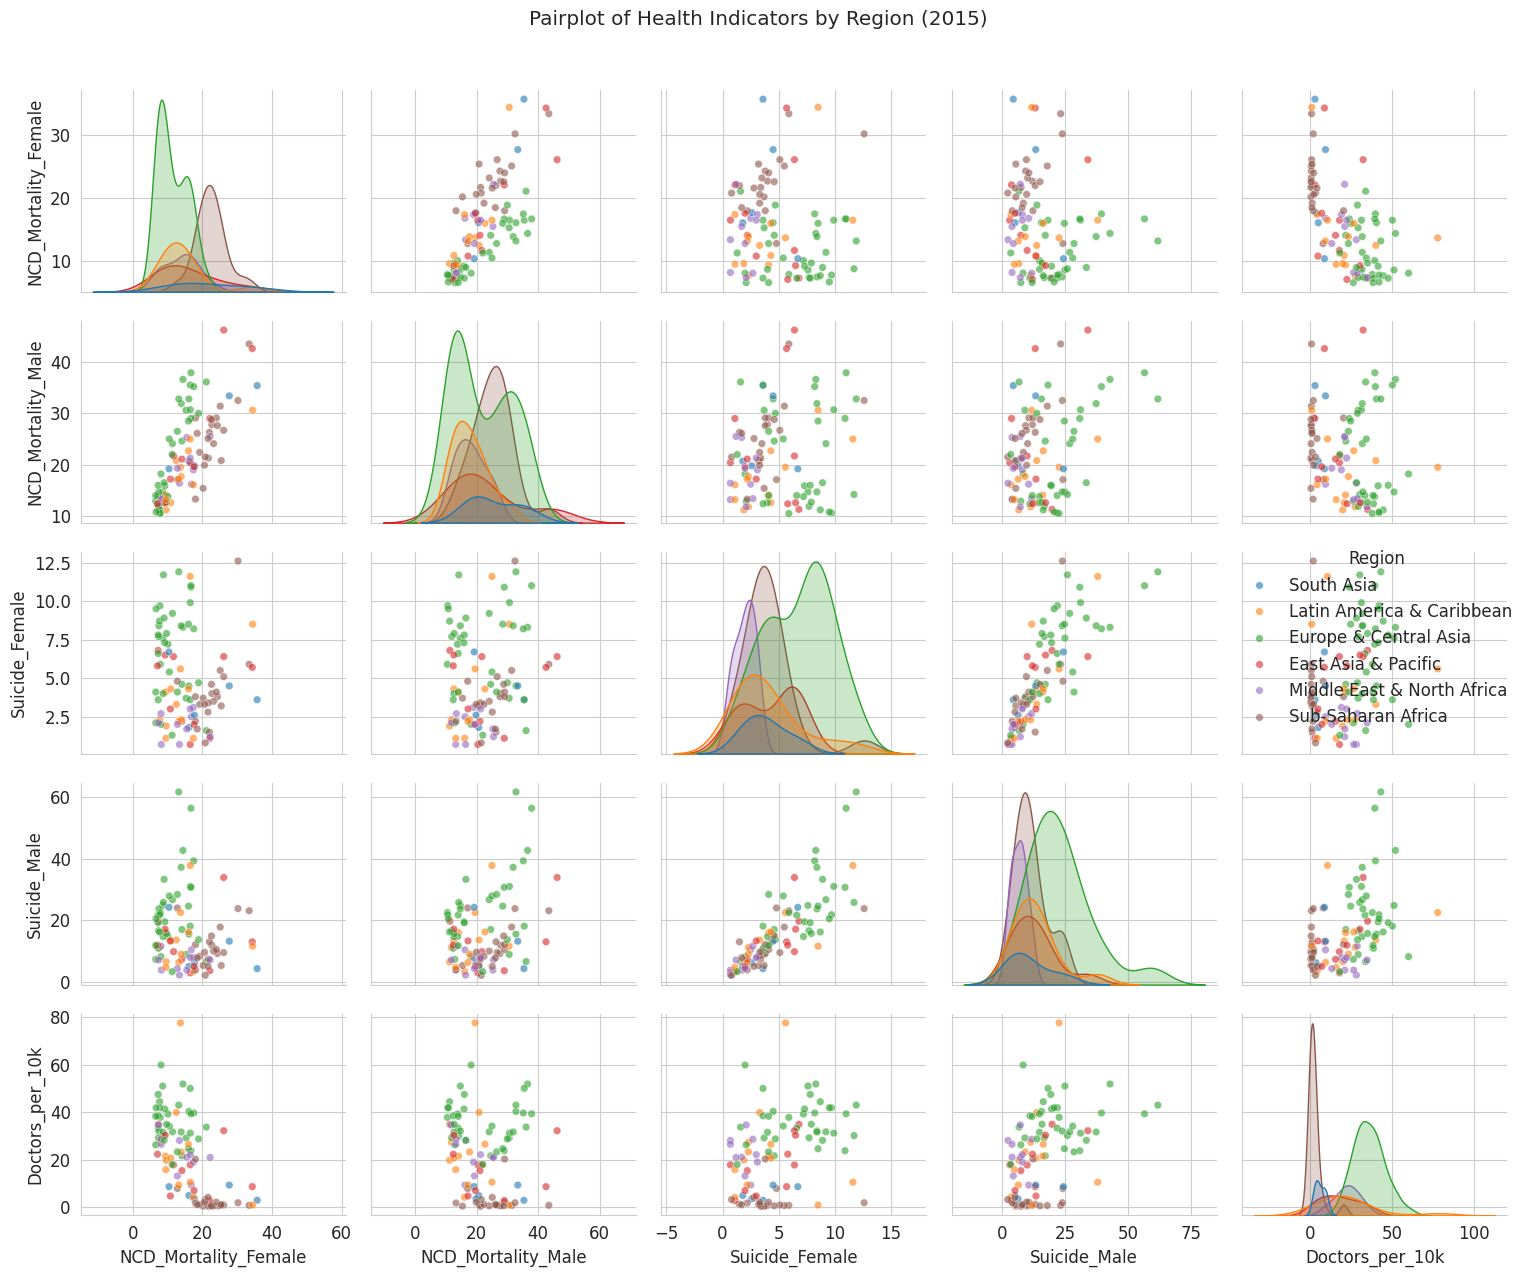

In [20]:
# Cell 20: Pairplot to see multivariate relationships
# Limit to a subset to avoid overcrowding
pair_vars = numeric_cols + ['Region']
pair_data = recent[pair_vars].dropna().copy()
# Sample if too many points
if len(pair_data) > 500:
    pair_data = pair_data.sample(500, random_state=42)

g = sns.pairplot(pair_data, hue='Region', diag_kind='kde',
                 plot_kws={'alpha': 0.6, 's': 30})
g.fig.suptitle('Pairplot of Health Indicators by Region (2015)', y=1.02)
plt.tight_layout()
plt.savefig('pairplot_2015.png', dpi=150)
plt.show()

In [ ]:
# Cell 21: Create a pivot table of average NCD mortality by region and year
pivot_ncd_female = merged.pivot_table(values='NCD_Mortality_Female',
                                       index='Year', columns='Region', aggfunc='mean')
pivot_ncd_female = pivot_ncd_female.dropna(how='all', axis=1)

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_ncd_female.T, cmap='RdYlGn_r', annot=True, fmt='.1f',
            cbar_kws={'label': 'NCD Mortality Female (%)'})
plt.title('Average NCD Mortality Female by Region Over Time')
plt.ylabel('Region')
plt.xlabel('Year')
plt.tight_layout()
plt.savefig('ncd_female_heatmap.png', dpi=150)
plt.show()

In [21]:
# Cell 22: Save the merged dataframe to CSV
merged.to_csv("cleaned_life_expectancy_data.csv", index=False)
print("Cleaned data saved to 'cleaned_life_expectancy_data.csv'")

Cleaned data saved to 'cleaned_life_expectancy_data.csv'


In [22]:
# Cell 23: Download the cleaned data from Colab to your computer
from google.colab import files
files.download("cleaned_life_expectancy_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:


# Set style for better visuals
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load the two new files
state_le = pd.read_csv("U.S._State_Life_Expectancy_by_Sex__2019.csv")
historical = pd.read_csv("NCHS_-_Death_rates_and_life_expectancy_at_birth.csv")

print("State-level data shape:", state_le.shape)
print("Historical data shape:", historical.shape)

State-level data shape: (156, 5)
Historical data shape: (1071, 5)


In [24]:
# First few rows
state_le.head()

,State,Sex,LEB,SE,Quartile
0,Hawaii,Total,80.9,0.119,79.5 - 80.9
1,California,Total,80.9,0.022,79.5 - 80.9
2,New York,Total,80.7,0.030,79.5 - 80.9
3,Minnesota,Total,80.4,0.056,79.5 - 80.9
4,Massachusetts,Total,80.4,0.050,79.5 - 80.9


In [25]:
state_le.isnull().sum()

,0
State,0
Sex,0
LEB,0
SE,3
Quartile,0


In [26]:
state_le['Sex'].value_counts()

,count
Sex,
Total,52
Male,52
Female,52


In [27]:
historical.head()

,Year,Race,Sex,Average Life Expectancy (Years),Age-adjusted Death Rate
0,1900,All Races,Both Sexes,47.3,2518.0
1,1901,All Races,Both Sexes,49.1,2473.1
2,1902,All Races,Both Sexes,51.5,2301.3
3,1903,All Races,Both Sexes,50.5,2379.0
4,1904,All Races,Both Sexes,47.6,2502.5


In [28]:
historical.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1071 entries, 0 to 1070
Data columns (total 5 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Year                             1071 non-null   int64  
 1   Race                             1071 non-null   object 
 2   Sex                              1071 non-null   object 
 3   Average Life Expectancy (Years)  1065 non-null   float64
 4   Age-adjusted Death Rate          1071 non-null   float64
dtypes: float64(2), int64(1), object(2)
memory usage: 42.0+ KB


In [29]:
historical.isnull().sum()

,0
Year,0
Race,0
Sex,0
Average Life Expectancy (Years),6
Age-adjusted Death Rate,0


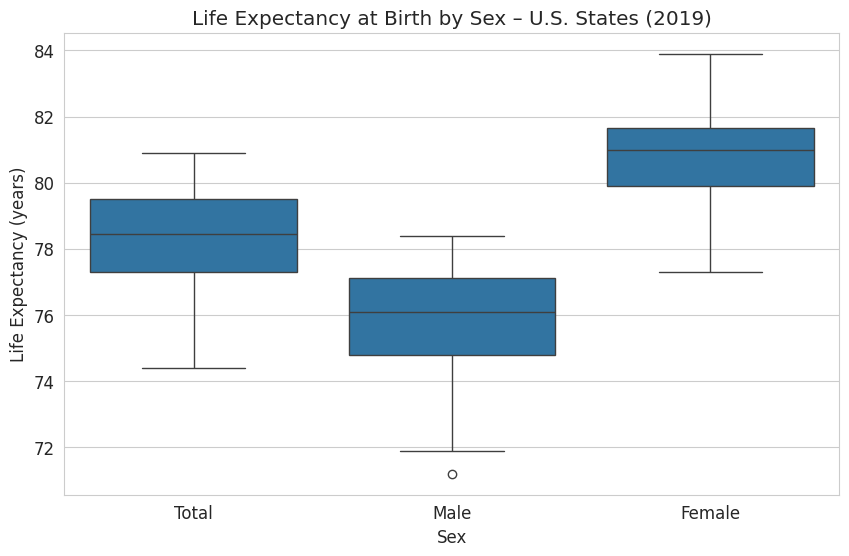

In [30]:
plt.figure(figsize=(10,6))
sns.boxplot(data=state_le, x='Sex', y='LEB')
plt.title('Life Expectancy at Birth by Sex – U.S. States (2019)')
plt.ylabel('Life Expectancy (years)')
plt.show()

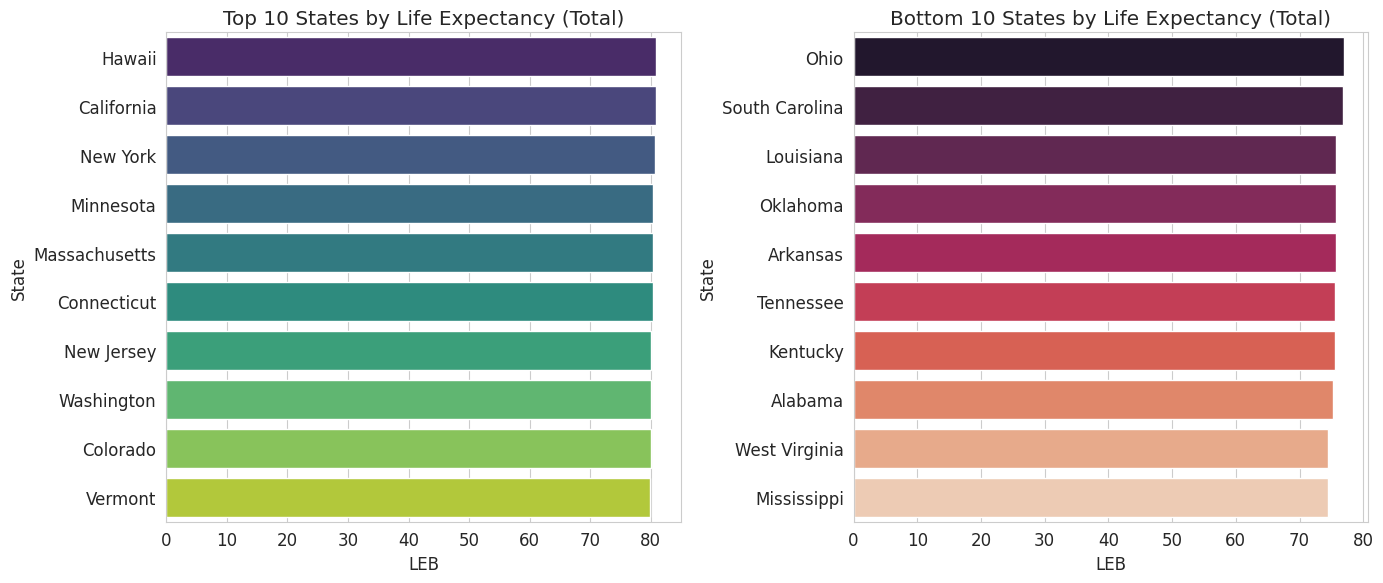

In [31]:
total_only = state_le[state_le['Sex'] == 'Total'].sort_values('LEB', ascending=False)

top10 = total_only.head(10)
bottom10 = total_only.tail(10)

fig, axes = plt.subplots(1,2, figsize=(14,6))
sns.barplot(data=top10, x='LEB', y='State', ax=axes[0], palette='viridis')
axes[0].set_title('Top 10 States by Life Expectancy (Total)')

sns.barplot(data=bottom10, x='LEB', y='State', ax=axes[1], palette='rocket')
axes[1].set_title('Bottom 10 States by Life Expectancy (Total)')

plt.tight_layout()
plt.show()

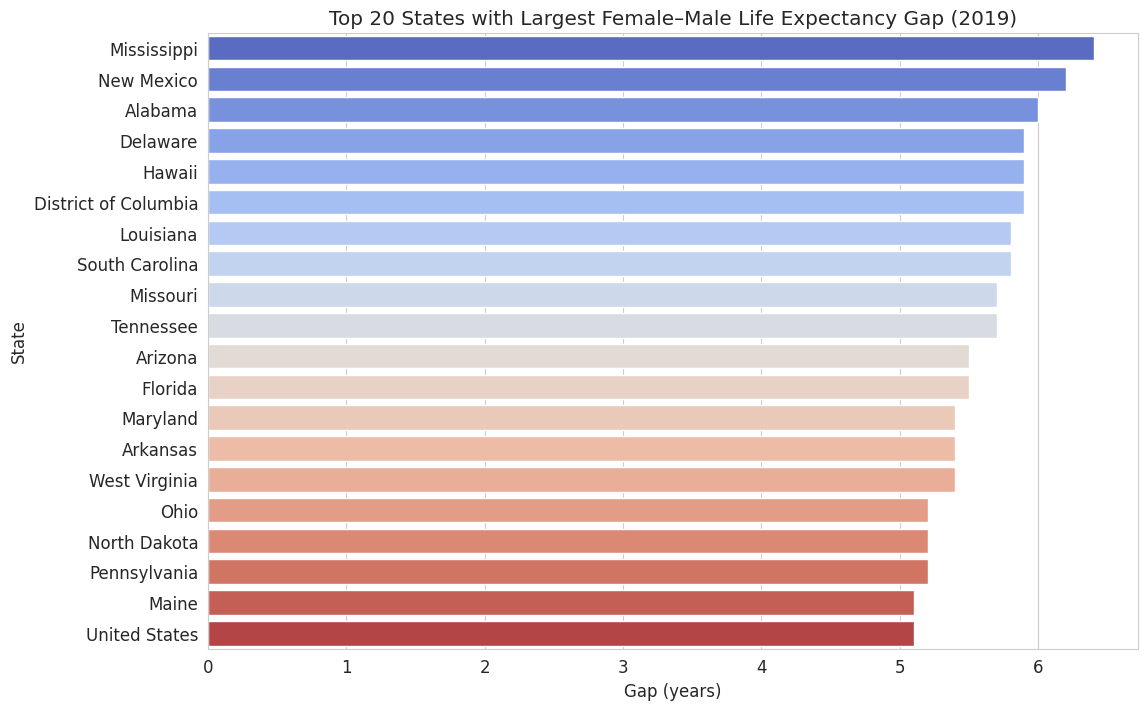

In [32]:
# Pivot to compare male/female
pivot = state_le.pivot(index='State', columns='Sex', values='LEB').reset_index()
pivot['Gap'] = pivot['Female'] - pivot['Male']

# Sort by gap
pivot_sorted = pivot.sort_values('Gap', ascending=False)

plt.figure(figsize=(12,8))
sns.barplot(data=pivot_sorted.head(20), x='Gap', y='State', palette='coolwarm')
plt.title('Top 20 States with Largest Female–Male Life Expectancy Gap (2019)')
plt.xlabel('Gap (years)')
plt.show()

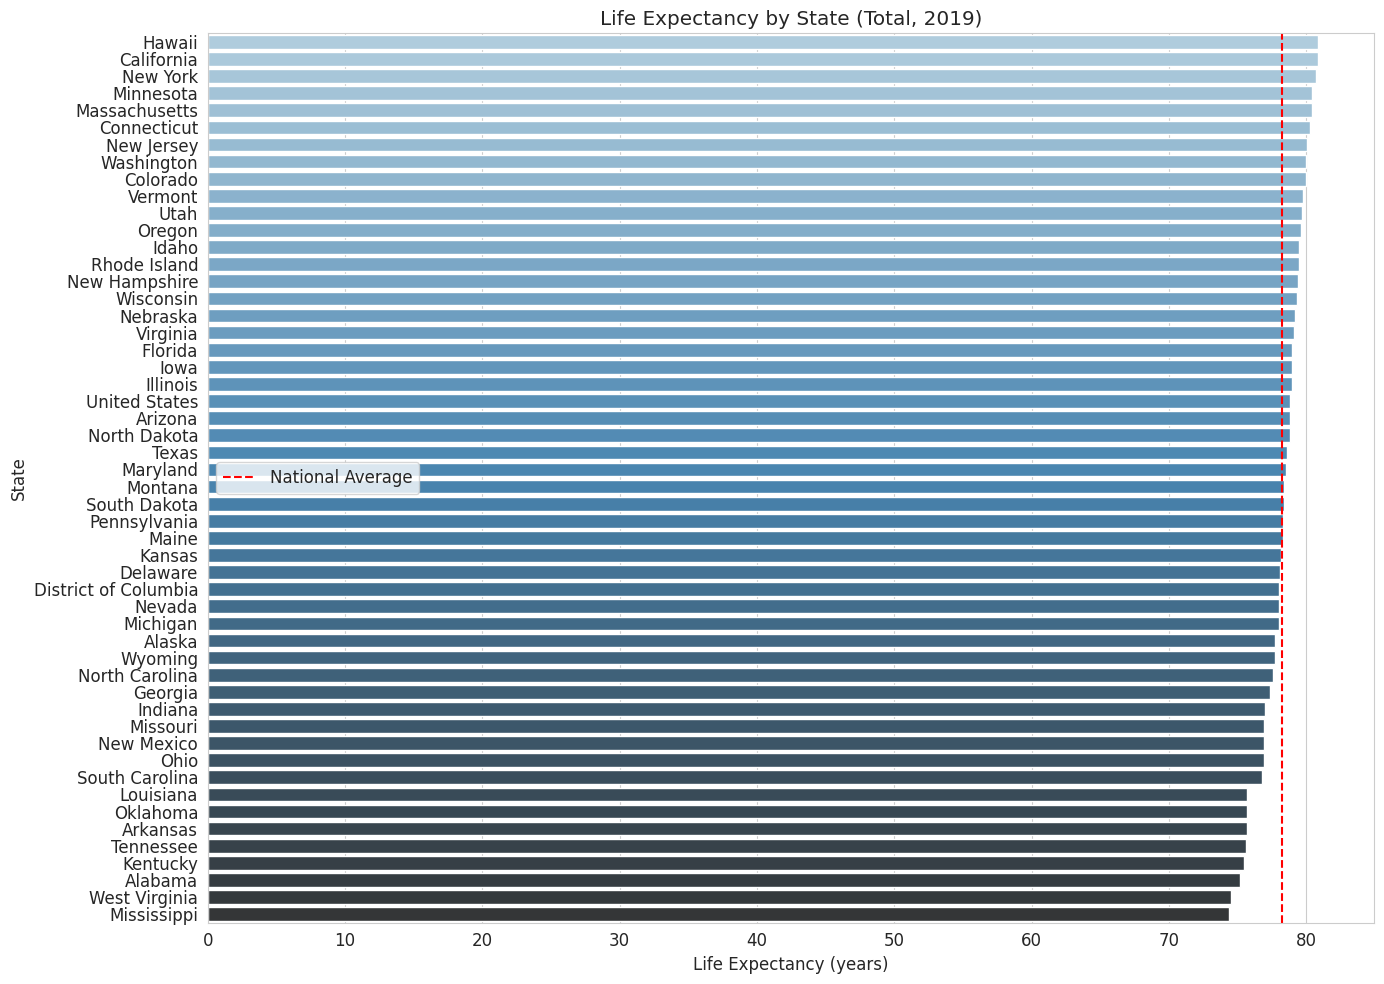

In [33]:
plt.figure(figsize=(14,10))
sns.barplot(data=total_only, x='LEB', y='State', palette='Blues_d')
plt.axvline(x=total_only['LEB'].mean(), color='red', linestyle='--', label='National Average')
plt.title('Life Expectancy by State (Total, 2019)')
plt.xlabel('Life Expectancy (years)')
plt.legend()
plt.tight_layout()
plt.show()

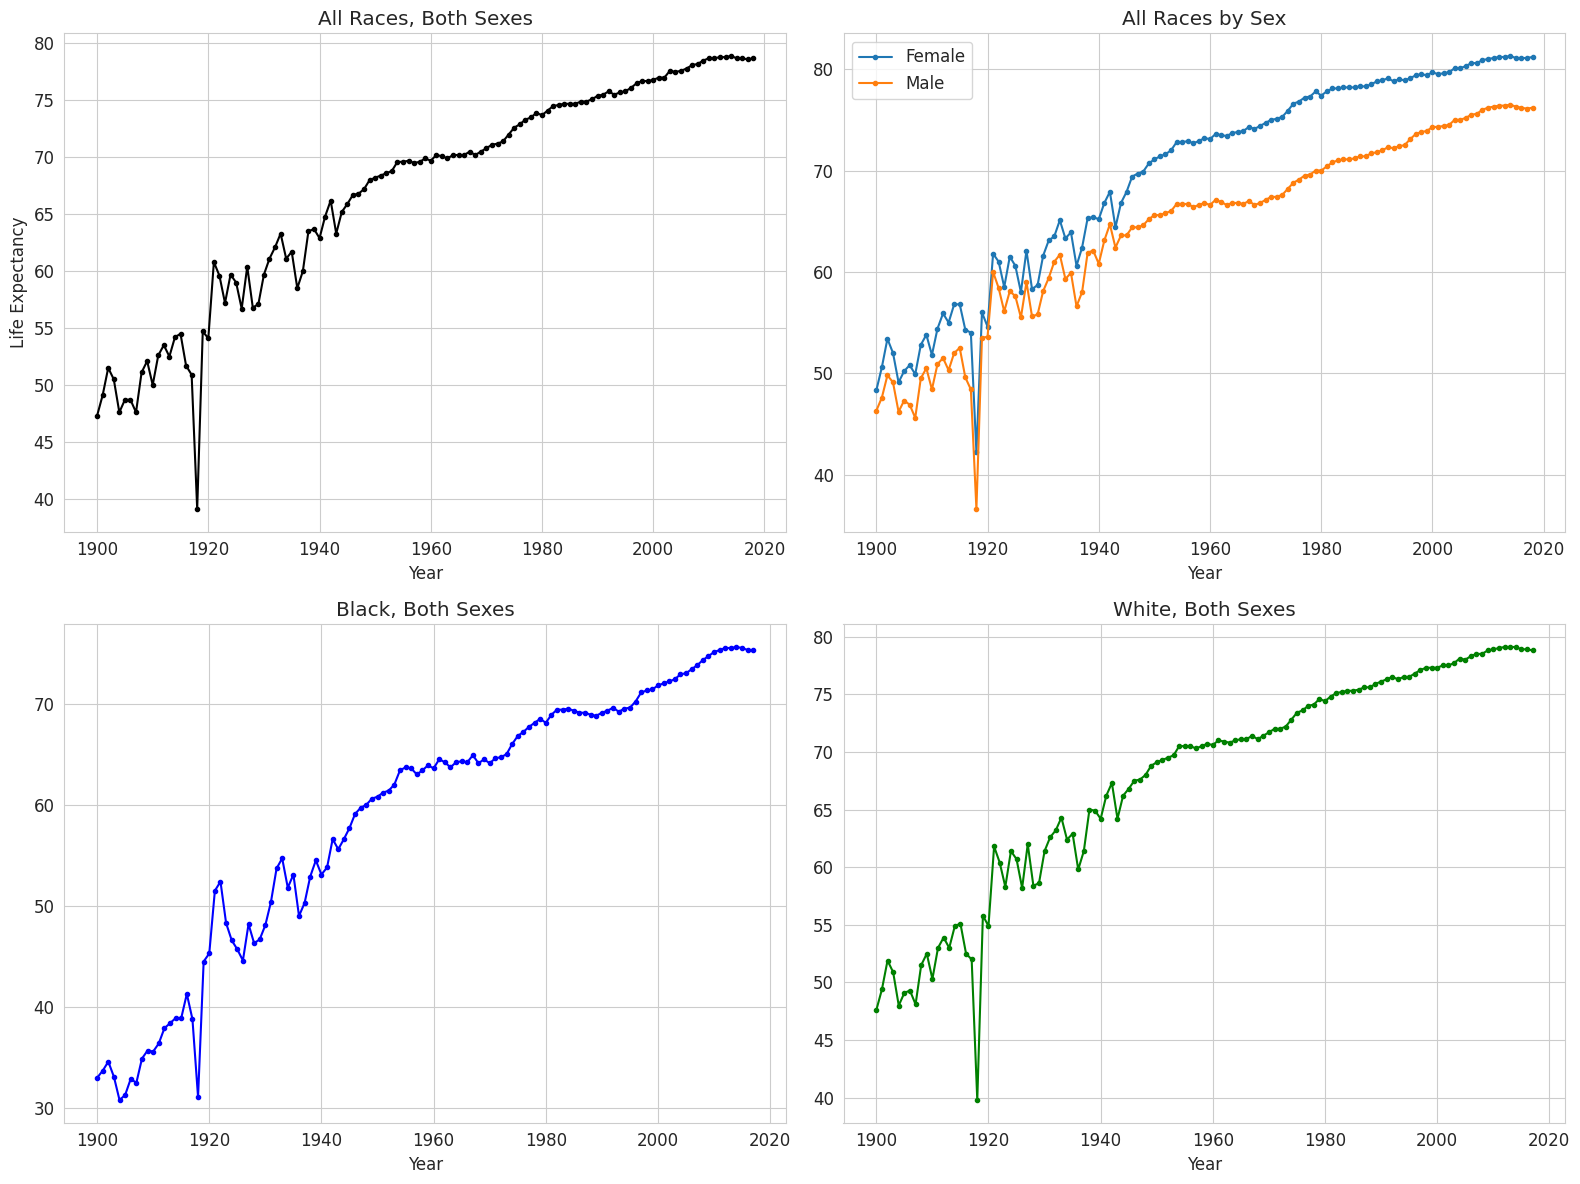

In [36]:
# Filter to relevant groups: All Races, Black, White; and Both Sexes, Female, Male
# We'll create separate line plots

fig, axes = plt.subplots(2,2, figsize=(16,12))

# All Races – Both Sexes
all_both = historical[(historical['Race']=='All Races') & (historical['Sex']=='Both Sexes')]
axes[0,0].plot(all_both['Year'], all_both['Average Life Expectancy (Years)'], marker='.', color='black')
axes[0,0].set_title('All Races, Both Sexes')
axes[0,0].set_ylabel('Life Expectancy')

# All Races – by Sex
all_female = historical[(historical['Race']=='All Races') & (historical['Sex']=='Female')]
all_male = historical[(historical['Race']=='All Races') & (historical['Sex']=='Male')]
axes[0,1].plot(all_female['Year'], all_female['Average Life Expectancy (Years)'], label='Female', marker='.')
axes[0,1].plot(all_male['Year'], all_male['Average Life Expectancy (Years)'], label='Male', marker='.')
axes[0,1].set_title('All Races by Sex')
axes[0,1].legend()

# Black, Both Sexes
black_both = historical[(historical['Race']=='Black') & (historical['Sex']=='Both Sexes')]
axes[1,0].plot(black_both['Year'], black_both['Average Life Expectancy (Years)'], color='blue', marker='.')
axes[1,0].set_title('Black, Both Sexes')

# White, Both Sexes
white_both = historical[(historical['Race']=='White') & (historical['Sex']=='Both Sexes')]
axes[1,1].plot(white_both['Year'], white_both['Average Life Expectancy (Years)'], color='green', marker='.')
axes[1,1].set_title('White, Both Sexes')

for ax in axes.flat:
    ax.set_xlabel('Year')
    ax.grid(True)

plt.tight_layout()
plt.show()

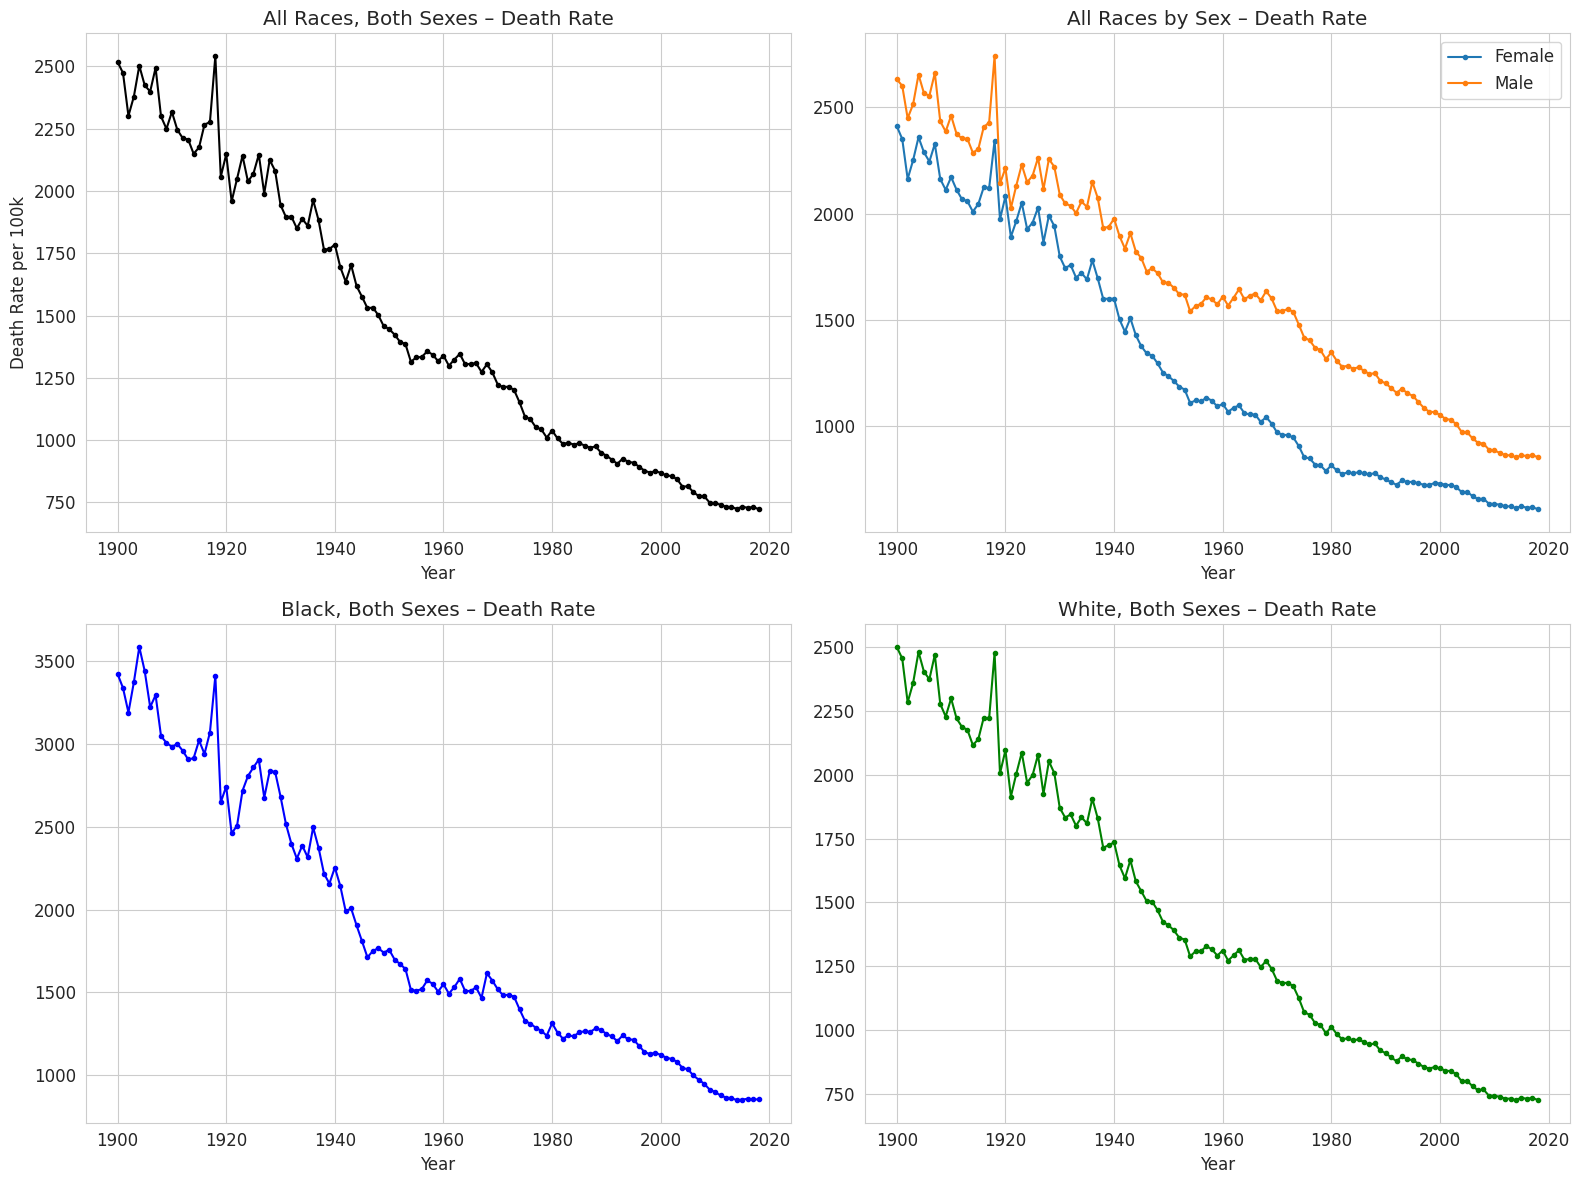

In [37]:
fig, axes = plt.subplots(2,2, figsize=(16,12))

# All Races – Both Sexes
axes[0,0].plot(all_both['Year'], all_both['Age-adjusted Death Rate'], color='black', marker='.')
axes[0,0].set_title('All Races, Both Sexes – Death Rate')
axes[0,0].set_ylabel('Death Rate per 100k')

# All Races by Sex
axes[0,1].plot(all_female['Year'], all_female['Age-adjusted Death Rate'], label='Female', marker='.')
axes[0,1].plot(all_male['Year'], all_male['Age-adjusted Death Rate'], label='Male', marker='.')
axes[0,1].set_title('All Races by Sex – Death Rate')
axes[0,1].legend()

# Black, Both Sexes
axes[1,0].plot(black_both['Year'], black_both['Age-adjusted Death Rate'], color='blue', marker='.')
axes[1,0].set_title('Black, Both Sexes – Death Rate')

# White, Both Sexes
axes[1,1].plot(white_both['Year'], white_both['Age-adjusted Death Rate'], color='green', marker='.')
axes[1,1].set_title('White, Both Sexes – Death Rate')

for ax in axes.flat:
    ax.set_xlabel('Year')
    ax.grid(True)

plt.tight_layout()
plt.show()

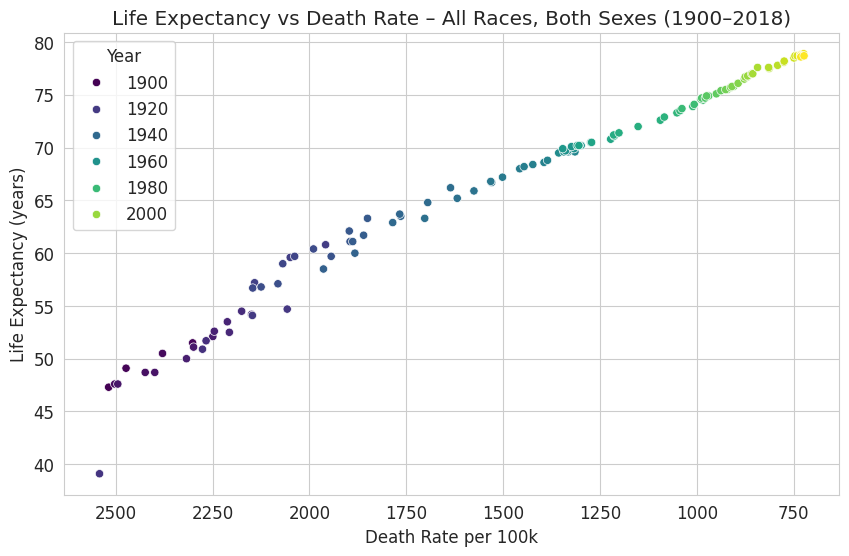

In [38]:
plt.figure(figsize=(10,6))
sns.scatterplot(data=all_both, x='Age-adjusted Death Rate', y='Average Life Expectancy (Years)', hue='Year', palette='viridis')
plt.title('Life Expectancy vs Death Rate – All Races, Both Sexes (1900–2018)')
plt.xlabel('Death Rate per 100k')
plt.ylabel('Life Expectancy (years)')
plt.gca().invert_xaxis()  # because death rate decreases over time
plt.show()

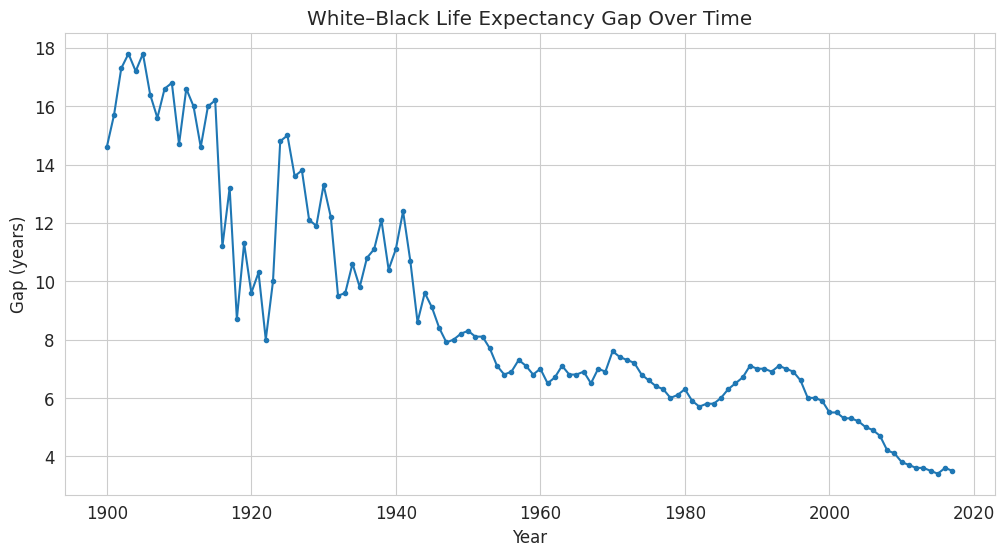

In [39]:
# Merge Black and White both‑sexes data
black_white = pd.merge(black_both[['Year','Average Life Expectancy (Years)']],
                       white_both[['Year','Average Life Expectancy (Years)']],
                       on='Year', suffixes=('_Black', '_White'))
black_white['Gap'] = black_white['Average Life Expectancy (Years)_White'] - black_white['Average Life Expectancy (Years)_Black']

plt.figure(figsize=(12,6))
plt.plot(black_white['Year'], black_white['Gap'], marker='.')
plt.title('White–Black Life Expectancy Gap Over Time')
plt.xlabel('Year')
plt.ylabel('Gap (years)')
plt.grid(True)
plt.show()

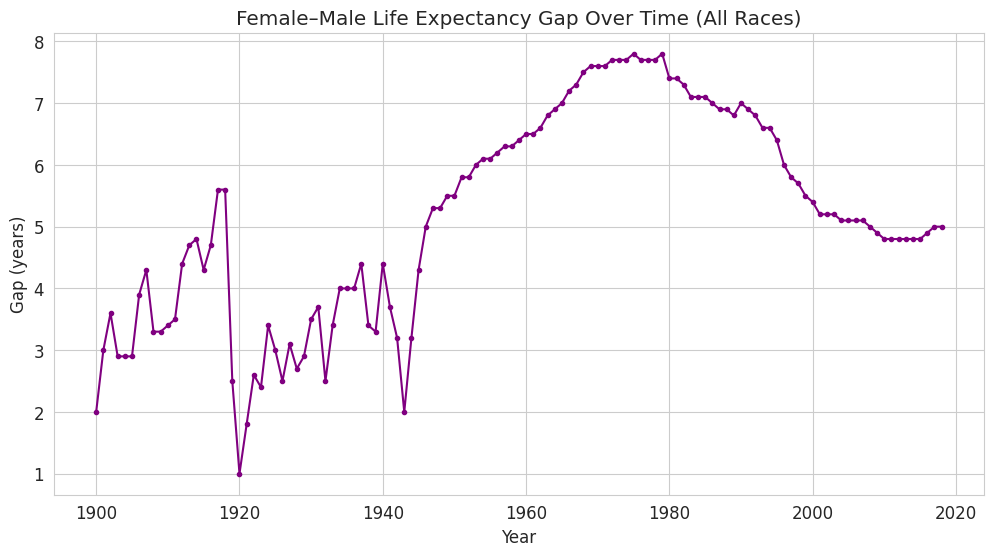

In [40]:
# For All Races, compute male–female gap
male_female = pd.merge(all_male[['Year','Average Life Expectancy (Years)']],
                       all_female[['Year','Average Life Expectancy (Years)']],
                       on='Year', suffixes=('_Male', '_Female'))
male_female['Gap'] = male_female['Average Life Expectancy (Years)_Female'] - male_female['Average Life Expectancy (Years)_Male']

plt.figure(figsize=(12,6))
plt.plot(male_female['Year'], male_female['Gap'], marker='.', color='purple')
plt.title('Female–Male Life Expectancy Gap Over Time (All Races)')
plt.xlabel('Year')
plt.ylabel('Gap (years)')
plt.grid(True)
plt.show()

National life expectancy (All Races, Both Sexes) in 2018: 78.7


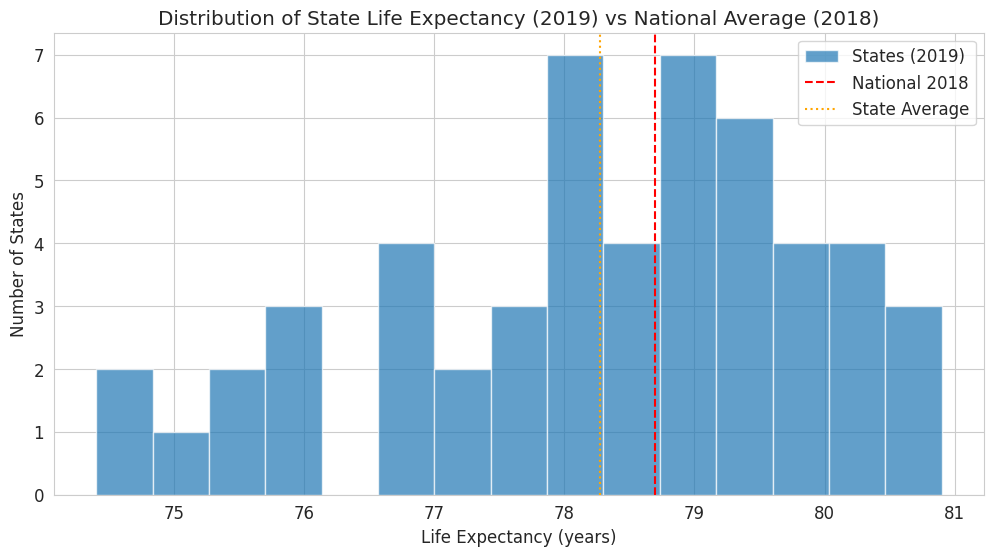

In [41]:
# Get the 2019 national value for All Races, Both Sexes (should be in historical if 2019 available, but last is 2018)
national_2018 = all_both[all_both['Year']==2018]['Average Life Expectancy (Years)'].values[0]
print(f"National life expectancy (All Races, Both Sexes) in 2018: {national_2018}")

# State totals for 2019
state_totals = state_le[state_le['Sex']=='Total']['LEB'].values

plt.figure(figsize=(12,6))
plt.hist(state_totals, bins=15, alpha=0.7, label='States (2019)')
plt.axvline(national_2018, color='red', linestyle='--', label='National 2018')
plt.axvline(np.mean(state_totals), color='orange', linestyle=':', label='State Average')
plt.xlabel('Life Expectancy (years)')
plt.ylabel('Number of States')
plt.title('Distribution of State Life Expectancy (2019) vs National Average (2018)')
plt.legend()
plt.show()